In [ ]:
#Load the data files from the google drive
from google.colab import drive
drive.mount('/content/drive')

pd.read_csv('/content/drive/MyDrive/MGR840_LAB1_DATA/vad_dataset_train.csv')
pd.read_csv('/content/drive/MyDrive/MGR840_LAB1_DATA/vad_dataset_test.csv')
pd.read_csv('/content/drive/MyDrive/MGR840_LAB1_DATA/traffic_24h.csv')

Mounted at /content/drive


,timestamp,hour,minute,is_peak_hour,traffic_lag_1,traffic_lag_2,traffic_lag_3,traffic_lag_4,offered_traffic_erlangs
0,00:00,0,0,0,6.74,6.74,6.74,6.74,6.74
1,00:15,0,15,0,6.74,6.74,6.74,6.74,8.68
2,00:30,0,30,0,8.68,6.74,6.74,6.74,6.75
3,00:45,0,45,0,6.75,8.68,6.74,6.74,7.83
4,01:00,1,0,0,7.83,6.75,8.68,6.74,7.67
...,...,...,...,...,...,...,...,...,...
91,22:45,22,45,0,6.76,8.48,7.90,9.17,8.41
92,23:00,23,0,0,8.41,6.76,8.48,7.90,6.78
93,23:15,23,15,0,6.78,8.41,6.76,8.48,8.22
94,23:30,23,30,0,8.22,6.78,8.41,6.76,7.70


***Partie1.py***

Voyelle: SQNR uniforme = 42.08 dB | SQNR loi-mu = 31.83 dB
Consonne: SQNR uniforme = 18.59 dB | SQNR loi-mu = 31.30 dB


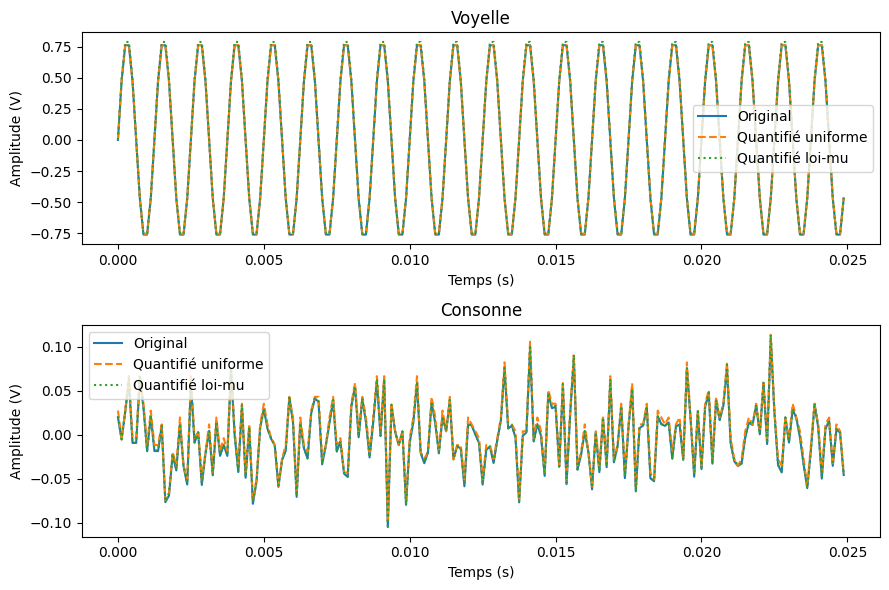

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def compress_mu_law(x, mu=255):
    """ Compression logarithmique Loi-mu (ITU-T G.711 North American Standard) """
    return np.sign(x) * np.log(1 + mu * np.abs(x)) / np.log(1 + mu)

def decompress_mu_law(y, mu=255):
    """ Décompression (expansion) Loi-mu """
    return np.sign(y) * ((1 + mu)**np.abs(y) - 1) / mu

def quantize_uniform(x, num_bits=8, v_max=1.0):
    """ Quantification uniforme mid-tread sur num_bits """
    levels = 2**num_bits
    q = (2 * v_max) / levels
    x_clipped = np.clip(x, -v_max, v_max)
    indices = np.round((x_clipped + v_max) / q)
    indices = np.clip(indices, 0, levels - 1)
    x_q = indices * q - v_max + (q / 2)
    return x_q

def compute_sqnr(x_original, x_quantized):
    """ Calcul du SQNR empirique en dB """
    p_signal = np.mean(x_original**2)
    p_noise = np.mean((x_original - x_quantized)**2)
    if p_noise == 0:
        return float('inf')
    return 10 * np.log10(p_signal / p_noise)

# Exemple de génération des phonèmes
fs = 8000
t = np.linspace(0, 0.1, int(fs * 0.1), endpoint=False)

# 1. Voyelle (Forte amplitude)
vowel = 0.8 * np.sin(2 * np.pi * 800 * t)

# 2. Consonne (Faible amplitude)
np.random.seed(42)
consonant = 0.04 * np.random.randn(len(t))

# --- PARTIE ÉTUDIANTS ---
# Calculer les SQNR Uniforme vs Loi-mu pour voyelle et consonne

signals = {'Voyelle': vowel, 'Consonne': consonant}

for name, x in signals.items():
    # Uniforme
    x_q_uniform = quantize_uniform(x, num_bits=8, v_max=1.0)
    sqnr_uniform = compute_sqnr(x, x_q_uniform)

    # Loi-mu
    x_compressed = compress_mu_law(x)
    x_compressed_q = quantize_uniform(x_compressed, num_bits=8, v_max=1.0)
    x_q_mulaw = decompress_mu_law(x_compressed_q)
    sqnr_mulaw = compute_sqnr(x, x_q_mulaw)

    print(f"{name}: SQNR uniforme = {sqnr_uniform:.2f} dB | SQNR loi-mu = {sqnr_mulaw:.2f} dB")

fig, axes = plt.subplots(2, 1, figsize=(9, 6))

for ax, (name, x) in zip(axes, signals.items()):
    x_q_uniform = quantize_uniform(x, num_bits=8, v_max=1.0)
    x_compressed = compress_mu_law(x)
    x_compressed_q = quantize_uniform(x_compressed, num_bits=8, v_max=1.0)
    x_q_mulaw = decompress_mu_law(x_compressed_q)

    ax.plot(t[:200], x[:200], label='Original', linewidth=1.5)
    ax.plot(t[:200], x_q_uniform[:200], label='Quantifié uniforme', linestyle='--')
    ax.plot(t[:200], x_q_mulaw[:200], label='Quantifié loi-mu', linestyle=':')
    ax.set_title(name)
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Amplitude (V)')
    ax.legend()

plt.tight_layout()
plt.savefig('screenshot_partie1_signaux.png', dpi=150)
plt.show()

***Partie 2***

label
1    5418
0    4582
Name: count, dtype: int64
label
1    0.5418
0    0.4582
Name: proportion, dtype: float64

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1319
           1       1.00      1.00      1.00      1681

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



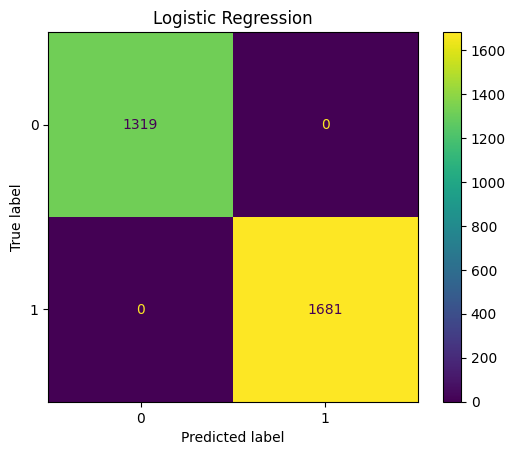


--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1319
           1       1.00      1.00      1.00      1681

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



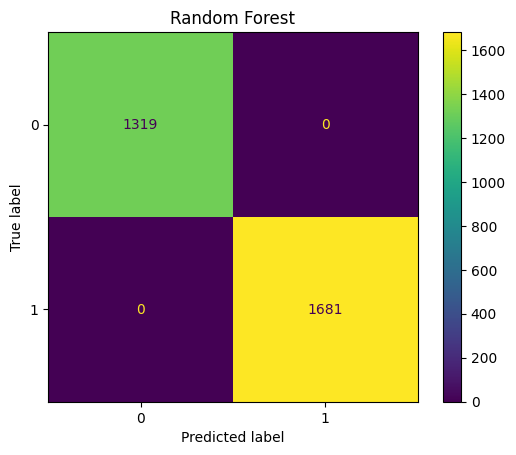

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Chargement des datasets fournis (depuis Drive vu qu'on est sur Colab et plus en local, car on travaille à 2 ;)
df_train = pd.read_csv('/content/drive/MyDrive/MGR840_LAB1_DATA/vad_dataset_train.csv')
df_test = pd.read_csv('/content/drive/MyDrive/MGR840_LAB1_DATA/vad_dataset_test.csv')

# 2. Séparation des caractéristiques (X) et de la cible (y)
feature_cols = ['energy', 'zcr', 'spectral_flatness', 'spectral_centroid']

X_train = df_train[feature_cols]
y_train = df_train['label']

X_test = df_test[feature_cols]
y_test = df_test['label']

# 3. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- PARTIE ÉTUDIANTS ---
# Checker aussi la distribution des classes
# Entraîner LogisticRegression et RandomForestClassifier
# Comparer les performances sur X_test_scaled et y_test

print(df_train['label'].value_counts())
print(df_train['label'].value_counts(normalize=True))

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

for name, y_pred in [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
    plt.title(name)
    plt.show()

***Partie 3***

In [ ]:
# Utilisation des prédictions du meilleur modèle (ex. Random Forest)
y_pred_best = rf_model.predict(X_test_scaled)

# Calcul du Facteur d'Activité Vocale (alpha)
alpha = np.mean(y_pred_best)

r_nominal = 64.0 # kbit/s (Canal DS0)
r_effective = alpha * r_nominal
bandwidth_savings = (1 - alpha) * 100

print(f"--- Bilan d'Économie Réseau ---")
print(f"Trames analysées dans le test set : {len(y_pred_best)}")
print(f"Facteur d'activité vocale (alpha)  : {alpha:.3f}")
print(f"Débit effectif moyen par voie      : {r_effective:.2f} kbit/s")
print(f"Économie de bande passante         : {bandwidth_savings:.2f} %")

--- Bilan d'Économie Réseau ---
Trames analysées dans le test set : 3000
Facteur d'activité vocale (alpha)  : 0.560
Débit effectif moyen par voie      : 35.86 kbit/s
Économie de bande passante         : 43.97 %


***Partie 4***

--- Dimensionnement Statique (Heure de Pointe) ---
Trafic de pointe : 35.0 Erlangs
Canaux requis    : 47 (soit 2 liaisons T1 de 24 canaux)
Ressources dynamiques (canaux x heures) : 229.2
Ressources statique (canaux x heures)   : 340.8
Gain : 32.72 %


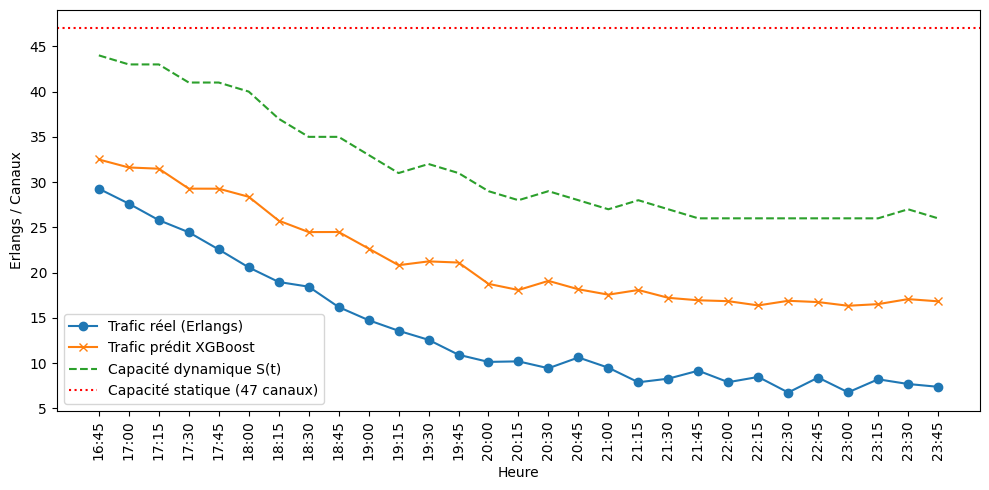

In [ ]:
from xgboost import XGBRegressor

def erlang_b(A, S):
    """ Calcul récursif de la probabilité de blocage Erlang B """
    pb = 1.0
    for k in range(1, S + 1):
        pb = (A * pb) / (k + A * pb)
    return pb

def find_min_channels(A, target_pb=0.01):
    """ Trouve le nombre minimal de canaux S pour garantir Pb <= target_pb """
    S = 1
    while True:
        if erlang_b(A, S) <= target_pb:
            return S
        S += 1

# 1. Calcul Statique
A_peak = 35.0 # Erlangs à l'heure de pointe
S_static = find_min_channels(A_peak, target_pb=0.01)
t1_count_static = int(np.ceil(S_static / 24))

print(f"--- Dimensionnement Statique (Heure de Pointe) ---")
print(f"Trafic de pointe : {A_peak} Erlangs")
print(f"Canaux requis    : {S_static} (soit {t1_count_static} liaisons T1 de 24 canaux)")

# 2. Chargement des données de trafic 24h
#df_traffic = pd.read_csv('traffic_24h.csv') # Contient les colonnes 'timestamp' et 'offered_traffic_erlangs'
df_traffic = pd.read_csv('/content/drive/MyDrive/MGR840_LAB1_DATA/traffic_24h.csv')

# --- PARTIE ÉTUDIANTS ---
# 1. Générer les colones lag_1, lag_2, lag_3, lag_4
# 2. Entrainer XGBRegressor
# 3. Calculer la capacitée dynamique S(t) et le gain en ressources sur 24h

feature_cols = ['hour', 'minute', 'is_peak_hour', 'traffic_lag_1', 'traffic_lag_2', 'traffic_lag_3', 'traffic_lag_4']
X = df_traffic[feature_cols]
y = df_traffic['offered_traffic_erlangs']

split = int(0.7 * len(df_traffic))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# Auto-scaling dynamique
S_dyn = [find_min_channels(max(A, 0.01), target_pb=0.01) for A in y_pred]
df_test_result = df_traffic.iloc[split:].copy()
df_test_result['S_dyn'] = S_dyn

# Comparaison canaux x heures (chaque ligne = 15 min = 0.25h)
resources_dynamic = sum(s * 0.25 for s in S_dyn)
resources_static = S_static * 0.25 * len(y_test)

print(f"Ressources dynamiques (canaux x heures) : {resources_dynamic:.1f}")
print(f"Ressources statique (canaux x heures)   : {resources_static:.1f}")
print(f"Gain : {(1 - resources_dynamic/resources_static)*100:.2f} %")

plt.figure(figsize=(10, 5))
plt.plot(df_test_result['timestamp'], y_test.values, label='Trafic réel (Erlangs)', marker='o')
plt.plot(df_test_result['timestamp'], y_pred, label='Trafic prédit XGBoost', marker='x')
plt.plot(df_test_result['timestamp'], S_dyn, label='Capacité dynamique S(t)', linestyle='--')
plt.axhline(y=S_static, color='red', linestyle=':', label=f'Capacité statique ({S_static} canaux)')
plt.xticks(rotation=90)
plt.xlabel('Heure')
plt.ylabel('Erlangs / Canaux')
plt.legend()
plt.tight_layout()
plt.savefig('screenshot_partie4_trafic_predit.png', dpi=150)
plt.show()